# EWSN
This hopefully the last document to do the analysis of the EWSN paper.

## Steps

### Best model determination
Determin the best model for each input, output pair.  
This model yields the highest f1 score on the validation set. 
Save all to a single csv using pandas or numpy. would be usefull later. 

### Results
The first result is the finding an optimal model based on the best input, output pair. 
--> first check if the threshold makes sense. 
We therefore need to calculate for each best model obtained by the prevuous step the --> extend this in the dataset. 

# Compression factor 
dertermin this later --> we have the code laying somewhere.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json 
from dataclasses import dataclass
import matplotlib.cm as cm
import pandas as pd

fn_base = '../Results/EWSN_ds_{}/ResNet_{}/res_{}/'

## General info 
bits_decoded = 56 # number of decoded bits of packet
bits_sample = 16 # 8 I and 8 Q
samples_packet = 237 # IQ samples
bits_packet = bits_sample*samples_packet
bytes_packet = np.ceil(bits_packet/8)
print(bits_packet,bytes_packet)


3792 474.0


## Best models
We calculated the f1 an so forth using the EWSN_process_results.py. Here We load the results and select for each pair of inputs and outputs the best model. The modes are saved in a csv. 

In [2]:
class Model:
    def __init__(self,in_size=16, out_size=4,res=0):
        self.fn = self.fn = fn_base.format(in_size,out_size,res)
        self.result = {
            'in_size':in_size,
            'out_size':out_size,
            'res':res,
            'downsample': 256//in_size
        }
        with open(self.fn+'Results/results.json','r') as file:
            self.result.update(json.load(file)) 

best_models = []
for in_size in [16,32,64,128,256]:
    for out_size in range(4,21,2):
        models = [Model(in_size,out_size,res) for res in range(3)]
        best_models.append(max(models,key=lambda x:x.result['val_f1']).result)

bm_df = pd.DataFrame(best_models)
bm_df.to_csv('res/best_models.csv')
bm_df.head()

,in_size,out_size,res,downsample,val_f1,val_pres,val_recall,val_th,f1,pres,recall
0,16,4,1,16,0.125408,0.080970,0.277956,0.147,0.084506,0.050813,0.250816
1,16,6,2,16,0.129748,0.086533,0.259187,0.098,0.090701,0.056219,0.234590
2,16,8,2,16,0.143042,0.097799,0.266179,0.120,0.101810,0.064663,0.239251
3,16,10,2,16,0.135266,0.086453,0.310693,0.125,0.099086,0.059511,0.295780
4,16,12,0,16,0.139486,0.093980,0.270432,0.116,0.100059,0.062115,0.257122


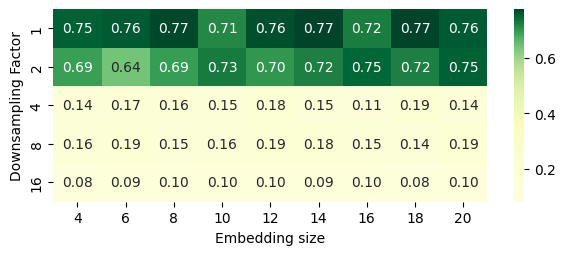

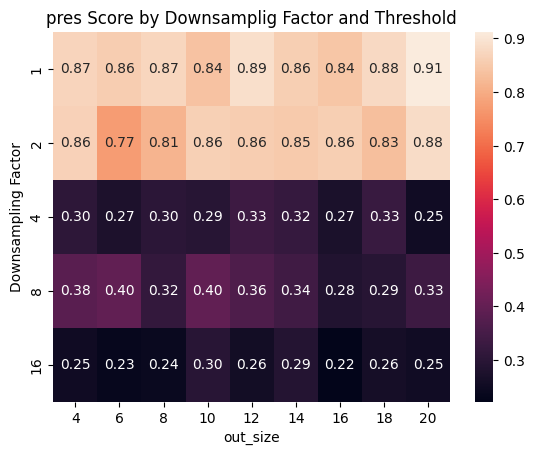

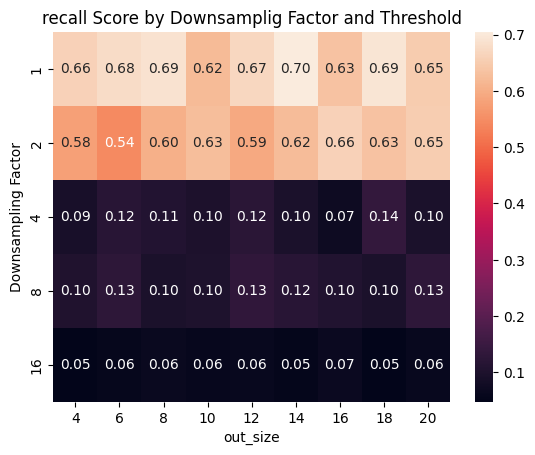

In [75]:
# plotje
import seaborn as sns
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap

x = np.linspace(0.3, 1, 256)
y = np.exp(x*5)
y = y/np.max(y)
# y=x
# Get the original colormap
original_cmap = cm.get_cmap('YlGn')
new_cmap = ListedColormap(original_cmap(y))

pivot = bm_df.pivot(index='downsample', columns='out_size', values='f1')
plt.figure(figsize=(7,2.5))
sns.heatmap(pivot, annot=True, fmt=".2f",cmap=new_cmap)
plt.ylabel("Downsampling Factor")
plt.xlabel("Embedding size")
# plt.title("F1 Score by Downsamplig Factor and Threshold")
plt.show()

pivot = bm_df.pivot(index='downsample', columns='out_size', values='recall')
sns.heatmap(pivot, annot=True, fmt=".2f")
plt.ylabel("Downsampling Factor")
plt.title("pres Score by Downsamplig Factor and Threshold")
plt.show()
import seaborn as sns
pivot = bm_df.pivot(index='downsample', columns='out_size', values='pres')
sns.heatmap(pivot, annot=True, fmt=".2f")
plt.ylabel("Downsampling Factor")
plt.title("recall Score by Downsamplig Factor and Threshold")
plt.show()

/home/dverbrug/miniconda3/envs/SyncSense/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


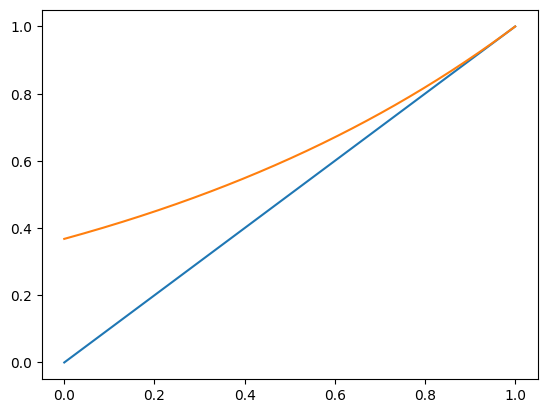

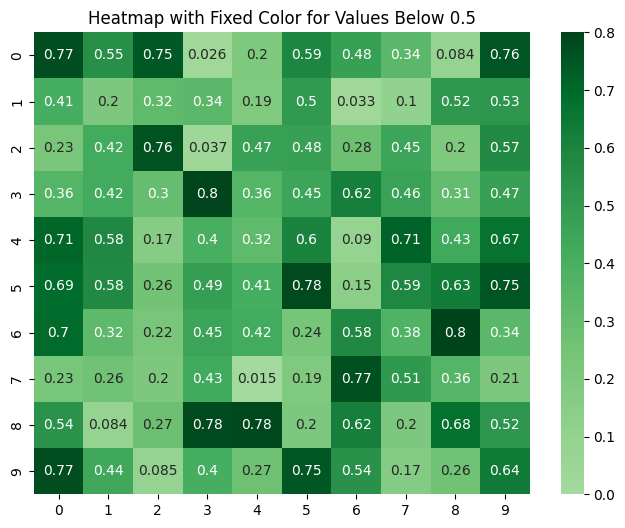

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

x = np.linspace(0, 1, 256)
y = np.exp(x)*6
y = y/np.max(y)
plt.plot(x,x)
plt.plot(x,y)
plt.show()


# Sample data
data = np.random.rand(10, 10) * 0.8
data[0, 0] = 0.77
data[1, 1] = 0.2  # Example value below 0.5

# Get the original colormap
original_cmap = cm.get_cmap('Greens')

# Create a new colormap with a fixed color for values below 0.5

colors = original_cmap(y)

new_cmap = ListedColormap(colors)

plt.figure(figsize=(8, 6))
sns.heatmap(data, cmap=new_cmap, annot=True, vmin=0, vmax=0.8)
plt.title('Heatmap with Fixed Color for Values Below 0.5')
plt.show()

## Quantisation 

In [4]:
# collect data

sizes = [4,6,8,10,12,14,16,18,20]
inputs = (128,256)
quanti = range(1,33)
for input_size in inputs:
    rows = []
    for output_shape in sizes:
        df_bm = pd.read_csv('../Analysis/res/best_models.csv', index_col=0)
        model = df_bm.loc[(df_bm['in_size']==input_size)&(df_bm['out_size']==output_shape)]
        in_size,out_size,res,downsample,val_f1,val_pres,val_recall,val_th,f1,pres,recall = model.values[0]
        fn_base = f'../Results/EWSN_ds_{int(in_size)}/ResNet_{int(out_size)}/res_{int(res)}'
        with open(fn_base+'/Results/quant.json','r') as file:
            result = json.load(file)
        for q in quanti:
            rows.append(result[str(q)])

    quantized = pd.DataFrame(rows)
    quantized.to_csv(f'res/model_quantisation_{input_size}.csv')
    quantized.head()
quantized.head()

,in_size,out_size,quant,tot_bits,tot_bytes,val_f1,val_pres,val_recall,val_th,f1,pres,recall
0,256,4.0,1,4.0,1.0,0.085849,0.044970,0.943694,0.132,0.057994,0.029940,0.920665
1,256,4.0,2,8.0,1.0,0.242789,0.140281,0.901677,0.132,0.167620,0.092764,0.868323
2,256,4.0,3,12.0,2.0,0.597313,0.499675,0.742376,0.132,0.558608,0.455943,0.720944
3,256,4.0,4,16.0,2.0,0.536930,0.582979,0.497624,0.132,0.562856,0.600957,0.529299
4,256,4.0,5,20.0,3.0,0.762478,0.679265,0.868924,0.132,0.711015,0.643557,0.794272


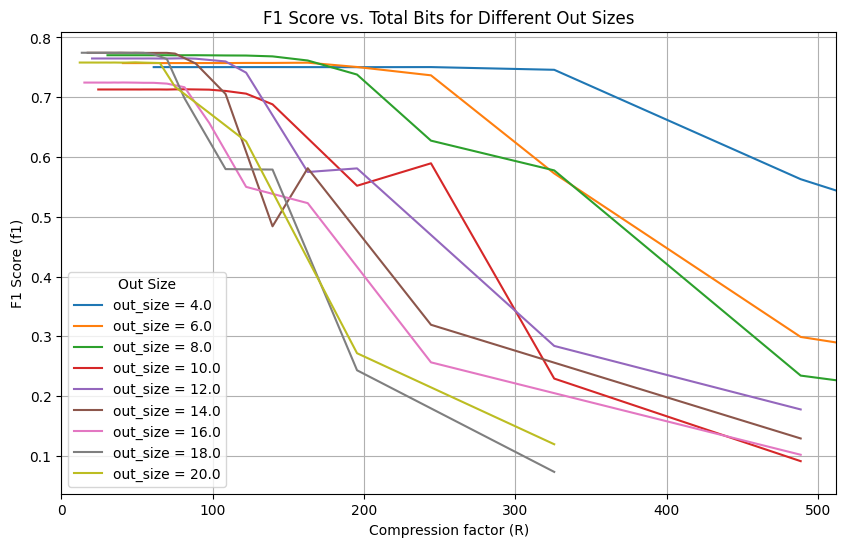

In [5]:
# continue with 256 
aggregated_df = quantized.groupby(['tot_bytes', 'out_size'])['f1'].max().reset_index()

plt.figure(figsize=(10, 6))  # Adjust figure size as needed

for out_size_val in aggregated_df['out_size'].unique():
    res = {}
    subset_df = aggregated_df[aggregated_df['out_size'] == out_size_val]
    res[f'CR'] = 976.9604843328152/subset_df['tot_bytes']
    res[f'f1'] = subset_df['f1']
    df_compress = pd.DataFrame(res)
    df_compress.to_csv(f'res/quant_{int(out_size_val)}.csv')
    plt.plot(976.9604843328152/subset_df['tot_bytes'], subset_df['f1'], linestyle='-', label=f'out_size = {out_size_val}')

plt.xlabel('Compression factor (R)')
plt.ylabel('F1 Score (f1)')
plt.title('F1 Score vs. Total Bits for Different Out Sizes')
plt.legend(title='Out Size')
plt.grid(True)
plt.xlim(0,512)
plt.show()

In [6]:
aggregated_df.head()
aggregated_df.to_csv('res/all.csv')

## Compression
We first need to know what the average packet length is for all detections in bytes. 
The compression factor = the average legnt/ our compression.

In [7]:
detections_file = '../Dataset/EWSN_disjunct/Okriftel_Testing_detections.pkl.gz'
sample_time = 1/12e6
detections = pd.read_pickle(detections_file, compression='gzip')
detections['t'] = detections.endIdx * sample_time # seconds
detections['tbin'] = np.floor(detections['t']).astype(int)
detections['IQ_len'] = detections.endIdx - detections.startIdx + 1
detections['bytes'] = (detections.endIdx - detections.startIdx + 1).clip(upper=512) * 2*16 / 8 # bytes
avg_packet_bytes = detections['bytes'].mean()
print(avg_packet_bytes)

## Only considering 
# load dataset
correlation_file = '../Dataset/EWSN_disjunct/Okriftel_Testing_correlation.csv.gz'
df = pd.read_csv(correlation_file, compression='gzip')
dd = set(pd.concat([df['i'], df['j']]))
avg_packet_bytes = detections[detections.index.isin(dd)]['bytes'].mean()
print(avg_packet_bytes)

976.9604843328152
976.0592


In [11]:
# Distribution of new dataset
df['bit_diff'].value_counts()[0]/len(df)

0.0032103220644128824

[1.         0.99828179 0.99515503 0.9911266  0.98638083 0.98102599
 0.97513635 0.96876731 0.96196248 0.95475758 0.94718259 0.93926333
 0.93102235 0.92247966 0.9136532  0.90455925 0.89521268 0.88562718
 0.87581545 0.86578931 0.85555987 0.84513755 0.83453223 0.82375327
 0.8128096  0.80170973 0.79046185 0.77907379 0.76755313 0.75590715
 0.74414295 0.73226737 0.72028709 0.70820859 0.69603823 0.68378219
 0.67144654 0.65903723 0.6465601  0.63402091 0.62142531 0.6087789
 0.5960872  0.58335567 0.57058971 0.55779471 0.54497598 0.53213884
 0.51928856 0.50643039 0.49356961 0.48071144 0.46786116 0.45502402
 0.44220529 0.42941029 0.41664433 0.4039128  0.3912211  0.37857469
 0.36597909 0.3534399  0.34096277 0.32855346 0.31621781 0.30396177
 0.29179141 0.27971291 0.26773263 0.25585705 0.24409285 0.23244687
 0.22092621 0.20953815 0.19829027 0.1871904  0.17624673 0.16546777
 0.15486245 0.14444013 0.13421069 0.12418455 0.11437282 0.10478732
 0.09544075 0.0863468  0.07752034 0.06897765 0.06073667 0.05281

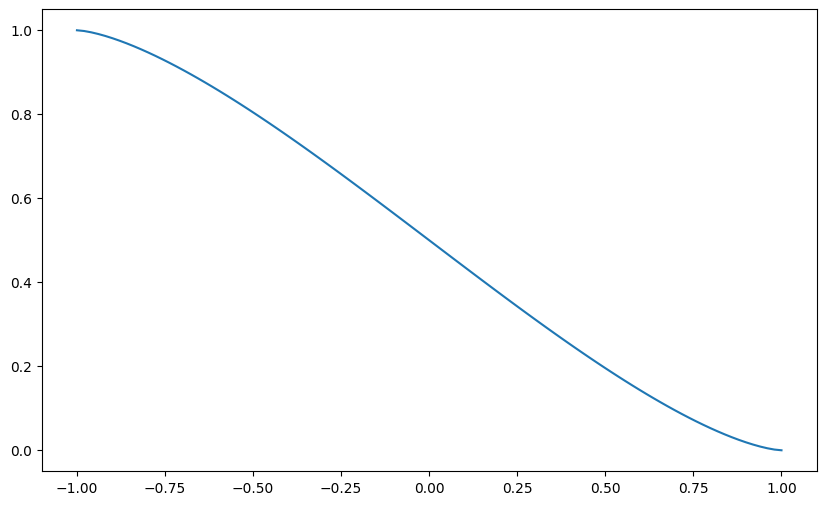

In [15]:
# corresponding distance in function of horison. 
# imagine two receivers, how big should the overlap be to be able to capture the same distribution. 
import numpy as np 
import matplotlib.pyplot as plt

h = np.linspace(-1,1,100)
R = 1 # horizon of the two receivers
A_t = np.pi*R*R
theta = np.arccos(h)
A_segment = theta
A_min = np.sin(theta)*h
A = (A_segment-A_min)/A_t
print(A)
# A_o = R*R*np.arccos(1-(d-R)/R)-(R-d)*np.sqrt(R**2-(R-d)**2)
plt.figure(figsize=(10,6))
plt.plot(h,A)
plt.show()

In [ ]:
# case 0: h>0
h_0 = np.linspace(0,1,100)
R = 1 # horizon of the two receivers
A_t = np.pi*R*R
theta = np.arccos(h) 
A_segment = theta
A_min = np.sin(theta) # 2*(b*h)/2
A = (A_segment-A_min)/A_t
print(A)
# A_o = R*R*np.arccos(1-(d-R)/R)-(R-d)*np.sqrt(R**2-(R-d)**2)
plt.figure(figsize=(10,6))
plt.plot(h,A)
plt.show()

In [21]:

class Model:
    def __init__(self,in_size=16, out_size=4, res=0):
        self.fn = fn_base.format(in_size,out_size,res)
        self.in_size = in_size
        self.out_size = out_size
        self.res = res
        data = Data(**np.load(self.fn+'Results/val.npy',allow_pickle=True).item())
        self.th = data.th
        self.recall,self.precision, self.f1 = data.cal_metrics(self.th)
    def row(self):
        return {'in_size':self.in_size,'out_size':self.out_size,'res':self.res,'th':self.th,'val_f1':self.f1,'val_recall':self.recall,'val_precision':self.precision}
@dataclass
class Data:
    A: np.ndarray
    T: np.ndarray
    Loss: np.ndarray
    Corr: np.ndarray
    flag: np.ndarray
    ham : np.ndarray

    @property
    def match(self): return self.flag==1

    @property
    def distance(self): return np.linalg.norm(self.A- self.T, axis=1)

    @property
    def th(self):
        # step 1: Sort on loss
        idx_s = np.argsort(self.distance)
        right = self.match[idx_s]
        distances = self.distance[idx_s]
        
        # step 2: devide in 4 groups: 
        TP = np.cumsum(right)               # Matching and accepted
        FP = np.cumsum(~right)              # Different but accepted
        # TN = np.cumsum(~right[::-1])[::-1]  # Different and rejected
        FN = np.cumsum(right[::-1])[::-1]   # Matching but rejected
        
        # step 3: calculate all metrics
        recall = TP/(TP+FN)
        precision = TP/(TP+FP)
        f1 = np.nan_to_num(2*precision*recall/(precision+recall))

        # return distances for which f1 is max
        return distances[np.argmax(f1)]

    def cal_metrics(self, th):
        predict = self.distance<th
        TP= np.sum(self.match&predict)
        TN= np.sum(~self.match&~predict)
        FP = np.sum(~self.match&predict)
        FN = np.sum(self.match&~predict)

        recall = TP/(TP+FN)
        precision = TP/(TP+FP)
        f1 =np.nan_to_num(2*precision*recall/(precision+recall))
        return recall, precision, f1

best_models = []
for in_size in [16,32,64,128,256]:
    for out_size in range(4,25,2):
        models = [Model(in_size,out_size,res) for res in range(3)]
        best_models.append(max(models,key=lambda x:x.f1).row())

bm_df = pd.DataFrame(best_models)
bm_df.to_csv('res/best_models.csv')
bm_df.head()

class Quantizer:
    """ This quantizer is build around the train data and applied to the test_data"""
    def __init__(self,features:np.ndarray, n_bits=32):
        self.k = 2 ** n_bits
        self.n_bits = n_bits
        f_min = np.min(features, axis=0, keepdims=True)
        f_max = np.max(features, axis=0, keepdims=True)
    
        scale = (f_max - f_min) / (self.k - 1)
        scale[scale == 0] = 1e-16  # Prevent division by zero

        self.f_min=f_min
        self.scale = scale

    def quantize(self,seq):
        return np.round((seq - self.f_min) / self.scale)  # or smaller dtype depending on bits
    
    def dequantize(self,seq):
        return self.f_min + seq * self.scale   
    
    def sim(self,seq):
        return self.f_min + np.round((seq - self.f_min) / self.scale)* self.scale  


FileNotFoundError: [Errno 2] No such file or directory: '../Results/EWSN_ds_256/ResNet_20/res_2Results/val.npy'

## Best Model results

In [ ]:
in_size=128
out_size = 24



df_bm = pd.read_csv('res/best_models.csv', index_col=0)
model = df_bm.loc[(df_bm['in_size']==in_size)&(df_bm['out_size']==out_size)]
in_size,out_size,res,th,*_ = model.values[0]
print(in_size,out_size,res,th,)

embeddings = np.load(f'../Results/EWSN_ds_{int(in_size)}/ResNet_{int(out_size)}/res_{int(res)}/Results/embeddings.npy',allow_pickle=True).item()
idx_array = embeddings['idx']
embedding_array = embeddings['embedding']
embedding_by_idx = {index: embedding for index, embedding in zip(idx_array, embedding_array)}

corr_file = '../Dataset/EWSN_disjunct/Okriftel_Testing_correlation.csv.gz'
corr = pd.read_csv(corr_file, compression='gzip')


128.0 24.0 1.0 0.28891507


In [60]:
# Get the embeddings for column 'i'
embeddings_i = corr['i'].map(embedding_by_idx).tolist()
embeddings_i_array = np.array(embeddings_i)

q = Quantizer(embeddings_i_array)
embeddings_i_array = q.sim(np.array(embeddings_i))



# Get the embeddings for column 'j'
embeddings_j = corr['j'].map(embedding_by_idx).tolist()
embeddings_j_array = q.sim(np.array(embeddings_j))

# Calculate the Euclidean distance using vectorized NumPy operations
corr['dist'] = np.linalg.norm(embeddings_i_array - embeddings_j_array, axis=1)

corr.head()

,i,j,corr,bit_diff,dist
0,1517,2333,0.999131,0,0.062436
1,4880,6057,0.999008,0,0.026013
2,3235,8129,0.998905,0,0.045042
3,3235,8891,0.998866,0,0.073138
4,1517,6057,0.998643,0,0.030114


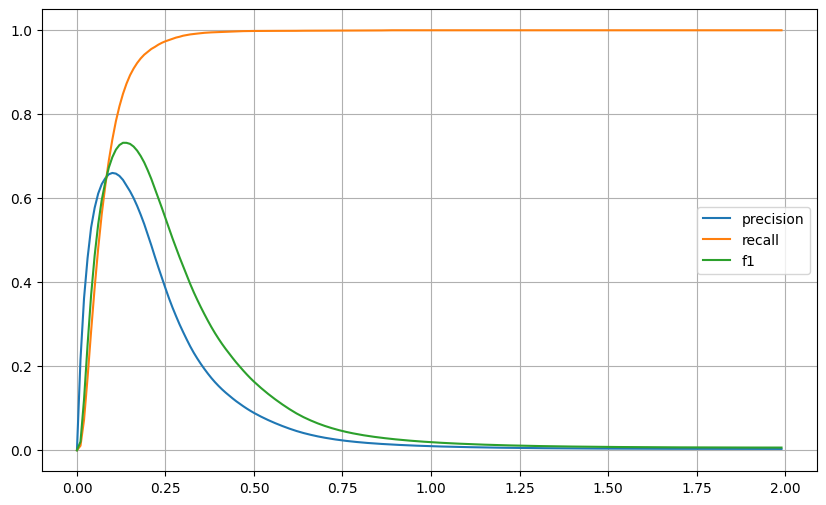

In [ ]:
## plot metrics: 
ths =  np.arange(0,2,0.01)
f1_arr = []
precision_arr = []
recall_arr = []

df = corr

# @property
#     def th(self):
#         # step 1: Sort on loss
#         idx_s = np.argsort(self.distance)
#         right = self.match[idx_s]
#         distances = self.distance[idx_s]
        
#         # step 2: devide in 4 groups: 
#         TP = np.cumsum(right)               # Matching and accepted
#         FP = np.cumsum(~right)              # Different but accepted
#         # TN = np.cumsum(~right[::-1])[::-1]  # Different and rejected
#         FN = np.cumsum(right[::-1])[::-1]   # Matching but rejected
        
#         # step 3: calculate all metrics
#         recall = TP/(TP+FN)
#         precision = TP/(TP+FP)
#         f1 = np.nan_to_num(2*precision*recall/(precision+recall))

#         # return distances for which f1 is max
#         return distances[np.argmax(f1)]
for th in ths:
    TP = df[(df['bit_diff'] == 0) & (df['dist'] < th)].shape[0]
    # TN = df[(df['bit_diff'] != 0) & (df['dist'] >= th)].shape[0]
    FP = df[(df['bit_diff'] != 0) & (df['dist'] < th)].shape[0]
    FN = df[(df['bit_diff'] == 0) & (df['dist'] >= th)].shape[0]

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    # Calculate F1 Score
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    f1_arr.append(f1)
    precision_arr.append(precision)
    recall_arr.append(recall)

plt.figure(figsize=(10,6))
plt.plot(ths,precision_arr,label='precision')
plt.plot(ths,recall_arr,label='recall')
plt.plot(ths,f1_arr,label='f1')
plt.grid(True)
plt.legend()
plt.show()


# General impressions
We will first only look at the losses (distances for the positives and the negatives). this gives an indication the general preformance. 

1. Plot the mean loss for both
2. plot the 99 and 95% regions for positive and negatives 

In [ ]:

class Models:
    def __init__(self, m_name='ResNet', out_size=4, bits=32, id=range(3)):
        self.out_size=out_size
        self.name=m_name
        self.model = max([Model(m_name=m_name,out_size=out_size,id=i, bits=bits)for i in id],key=lambda m: m.f1)
      

class Model:
    def __init__(self, m_name='ResNet', out_size=4,id=0,bits=32):
        self.out_size=out_size
        self.name=m_name
        self.nr_bits = bits
        self.fn = f'{fn}/{m_name}_{out_size}/res_{id}/'

        self.get_threshold()
        self.calc_metrics()

    def get_threshold(self):
        train = DataTrain(**np.load(self.fn+'Results/train.npy',allow_pickle=True).item())
        self.quantizer = train.re_init_quant(self.nr_bits)
        self.th = train.th
        self.train_recall,self.train_precision,self.train_f1, self.train_hit = train.cal_metrics(self.th)

    def calc_metrics(self):
        test = Data(**np.load(self.fn+'Results/test.npy',allow_pickle=True).item())
        test.set_quant(self.quantizer)
        self.recall,self.precision,self.f1, self.hit = test.cal_metrics(self.th)
        
        self.bits = self.out_size*self.nr_bits
        self.bytes = np.ceil(self.bits/8)
        self.data_vol_compress_bits = self.bits/bits_packet+self.hit
        self.data_vol_compress_bytes = self.bytes/bytes_packet+ self.hit
    
    def __repr__(self):
        return f'{self.name} {self.out_size}: f1({self.f1*100:.2f}%), pres({self.precision*100:.2f}%), recall({self.recall*100:.2f}%), bits({self.bits}), bytes({int(self.bytes)}); copr_bits({self.data_vol_compress_bits*100:.2f}%), compr_bytes({self.data_vol_compress_bytes*100:.2f}%) f1({self.train_f1*100:.2f}%), pres({self.train_precision*100:.2f}%), recall({self.train_recall*100:.2f}%)'

    def __str__(self):
        return f'{int(self.bits)},{int(self.bytes)}, {self.f1:.6f},{self.recall:.6f},{self.precision:.6f},{self.hit:.6f},{self.data_vol_compress_bits:.6f},{self.data_vol_compress_bytes:.6f}'





class Quantizer:
    """ This quantizer is build around the train data and applied to the test_data"""
    def __init__(self,features:np.ndarray, n_bits=32):
        self.k = 2 ** n_bits
        self.n_bits = n_bits
        f_min = np.min(features, axis=0, keepdims=True)
        f_max = np.max(features, axis=0, keepdims=True)
    
        scale = (f_max - f_min) / (self.k - 1)
        scale[scale == 0] = 1e-16  # Prevent division by zero

        self.f_min=f_min
        self.scale = scale

    def quantize(self,seq):
        return np.round((seq - self.f_min) / self.scale)  # or smaller dtype depending on bits
    
    def dequantize(self,seq):
        return self.f_min + seq * self.scale   
    
    def sim(self,seq):
        return self.f_min + np.round((seq - self.f_min) / self.scale)* self.scale  





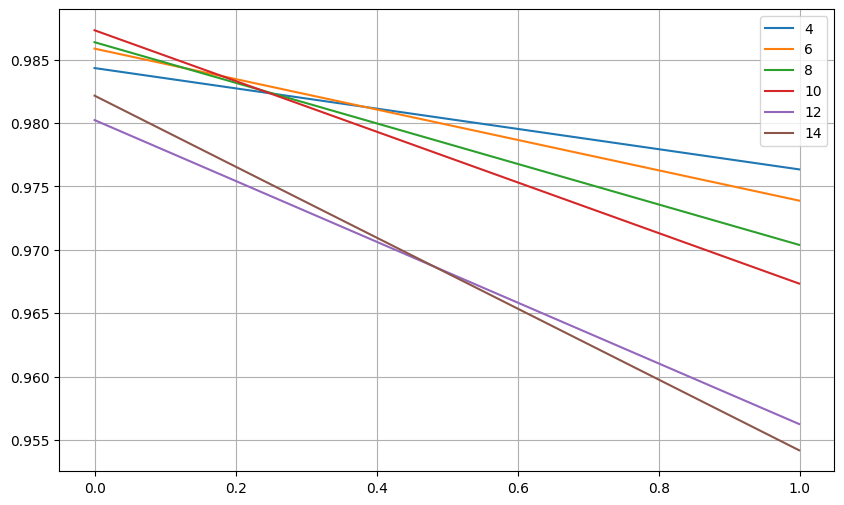

In [5]:
# Select model based on rate-distortion tradeoff
l = np.arange(0,1,0.001)
f = 500
name='ResNet'
b=32

plt.figure(figsize=(10,6))
for s in  [4,6,8,10,12,14]:
    m = Models(name, s, b)
    mm = m.model
    plt.plot(l,mm.f1-l*s/f, label=f'{s}')
plt.grid()
plt.legend()
plt.show()



In [19]:
# Resnet 12  is the best preforming model. Lets get all the data in funcion of the number of bits and bytes!
print(f'bits,bytes,f1,recall,precision,hitrate,bitsCompressed,bytesCompressed')
for b in range(1,32):
    m = Models('ResNet', 10, b)
    mm = m.model
    print(str(mm))

bits,bytes,f1,recall,precision,hitrate,bitsCompressed,bytesCompressed
10,2, 0.881362,0.875665,0.887134,0.329024,0.331661,0.333243
20,3, 0.897075,0.865779,0.930717,0.310076,0.315350,0.316405
30,4, 0.969072,0.982890,0.955638,0.342839,0.350750,0.351278
40,5, 0.983550,0.983270,0.983831,0.333143,0.343692,0.343692
50,7, 0.987335,0.992966,0.981767,0.337136,0.350321,0.351904
60,8, 0.987011,0.989544,0.984490,0.335044,0.350867,0.351922
70,9, 0.987124,0.991065,0.983214,0.335995,0.354455,0.354982
80,10, 0.987217,0.991065,0.983399,0.335932,0.357029,0.357029
90,12, 0.987311,0.991065,0.983585,0.335868,0.359602,0.361185
100,13, 0.987311,0.991065,0.983585,0.335868,0.362239,0.363294
110,14, 0.987311,0.991065,0.983585,0.335868,0.364877,0.365404
120,15, 0.987311,0.991065,0.983585,0.335868,0.367514,0.367514
130,17, 0.987311,0.991065,0.983585,0.335868,0.370151,0.371733
140,18, 0.987311,0.991065,0.983585,0.335868,0.372788,0.373843
150,19, 0.987311,0.991065,0.983585,0.335868,0.375425,0.375953
160,20, 0.987311

# Results

plot the compresion, the f1 score , the precision and recall for the two architectuers 

In [16]:
res = {}
for name in ['Transformer','ResNet']:
    r = {}
    for s in [4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36]:
        e = []
        for b in range(2,16):
            m = Models(name, s, b)
            mm = m.model
            e.append((mm.bits, mm.bytes,mm.data_vol_compress_bits,mm.data_vol_compress_bytes,mm.f1,mm.recall,mm.precision,mm.hit))
        r[s] = np.array(e).T
    res[name] = r
print(res)

/tmp/ipykernel_147923/3900188694.py:97: RuntimeWarning: invalid value encountered in divide
  f1 = np.nan_to_num(2*precision*recall/(precision+recall))


{'Transformer': {4: array([[ 8.        , 12.        , 16.        , 20.        , 24.        ,
        28.        , 32.        , 36.        , 40.        , 44.        ,
        48.        , 52.        , 56.        , 60.        ],
       [ 1.        ,  2.        ,  2.        ,  3.        ,  3.        ,
         4.        ,  4.        ,  5.        ,  5.        ,  6.        ,
         6.        ,  7.        ,  7.        ,  8.        ],
       [ 0.4047713 ,  0.42921018,  0.38736263,  0.39031862,  0.3826916 ,
         0.38742199,  0.39329306,  0.38046959,  0.38602381,  0.38606472,
         0.38724631,  0.38830117,  0.38967288,  0.3907911 ],
       [ 0.4047713 ,  0.43026504,  0.38736263,  0.39137347,  0.3826916 ,
         0.38847684,  0.39329306,  0.38152444,  0.38602381,  0.38711957,
         0.38724631,  0.38935602,  0.38967288,  0.39184595],
       [ 0.76425004,  0.82667112,  0.84220768,  0.84633028,  0.84239664,
         0.84480768,  0.84531898,  0.84344071,  0.84380867,  0.84340586,
      

In [17]:
print(res['Transformer'][4][0])

[ 8. 12. 16. 20. 24. 28. 32. 36. 40. 44. 48. 52. 56. 60.]


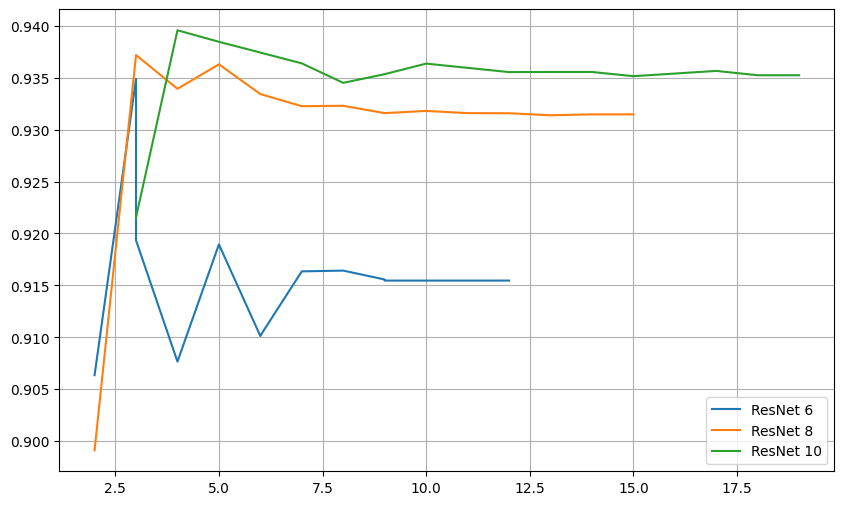

In [32]:
## plot transformers
x= 1  # 0 for bits, 1 for bytes
y = 4 # (2,comp_bits),(3,comp_bytes),(4,f1),(5,recall),(6,precision),(7,Hitrate)
name = 'ResNet'
res_temp = res[name]
plt.figure(figsize=(10,6))
for k in [6,8,10]:
    plt.plot(res_temp[k][x],res_temp[k][y], label=f'{name} {k}')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Best models! 
# Transformer 8,10,12 (with 4bits/feature or 5bits/feature)
# ResNet 6,8,10

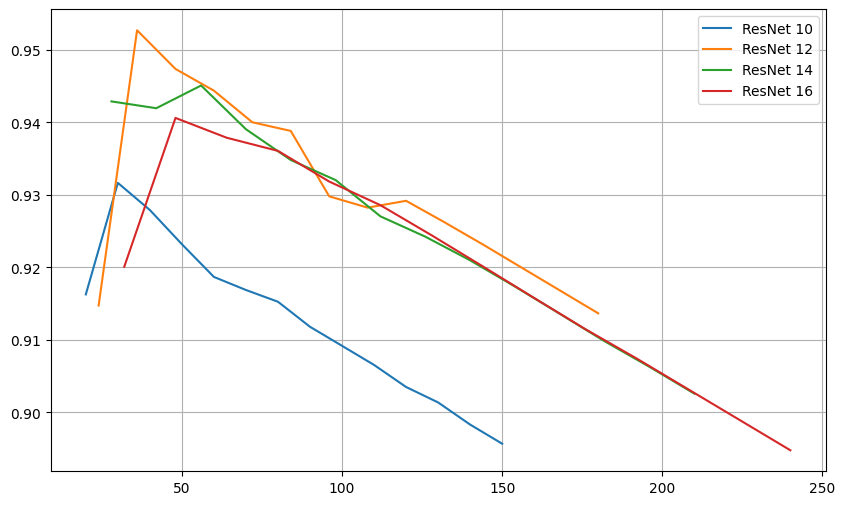

In [54]:
## plot transformers
x= 0  # 0 for bits, 1 for bytes
y = 4 # (2,comp_bits),(3,comp_bytes),(4,f1),(5,recall),(6,precision),(7,Hitrate)
z = 0
plt.figure(figsize=(10,6))
# name = 'Transformer'
# res_temp = res[name]
# for k in [8,10,12,14,16]:
#     plt.plot(res_temp[k][x],res_temp[k][y]-res_temp[k][z]/bits_packet, label=f'{name} {k}')

name = 'ResNet'
res_temp = res[name]
for k in [10,12,14,16]:
    plt.plot(res_temp[k][x],res_temp[k][y]-res_temp[k][z]/bits_packet, label=f'{name} {k}')

plt.legend()
plt.grid()
plt.show()

# Best model 
The best model is the model with the highest f1 score of training! I think this makes the most sense, no need to try and find another metric. 
1. per nr of features decidede best model [0,1,2,3]
2. Run validation 
3. Can this be compressed more? 

In [12]:
best_models = {}
for name in ['Transformer', 'ResNet']:
    t = Model_sizes(m_name=name)
    best_models[name] = [(m.out_size,m.best_f1) for m in t.models ]
        
print(best_models)


/tmp/ipykernel_433960/4247088273.py:112: RuntimeWarning: invalid value encountered in divide
  f1 = np.nan_to_num(2*precision*recall/(precision+recall))


{'Transformer': [(4, 0), (6, 1), (8, 2), (10, 0), (12, 2), (14, 3), (16, 0), (18, 0), (20, 3), (22, 0), (24, 1), (26, 1), (28, 3), (30, 0), (32, 0), (34, 1), (36, 3)], 'ResNet': [(4, 0), (6, 1), (8, 0), (10, 2), (12, 3), (14, 1), (16, 2), (18, 2), (20, 3), (22, 0), (24, 0), (26, 1), (28, 3), (30, 3), (32, 1), (34, 0), (36, 3)]}


# Quantization
We know which are the best models, but how does the quantisation of the features influence the model f1 score? 

/tmp/ipykernel_433960/4247088273.py:112: RuntimeWarning: invalid value encountered in divide
  f1 = np.nan_to_num(2*precision*recall/(precision+recall))


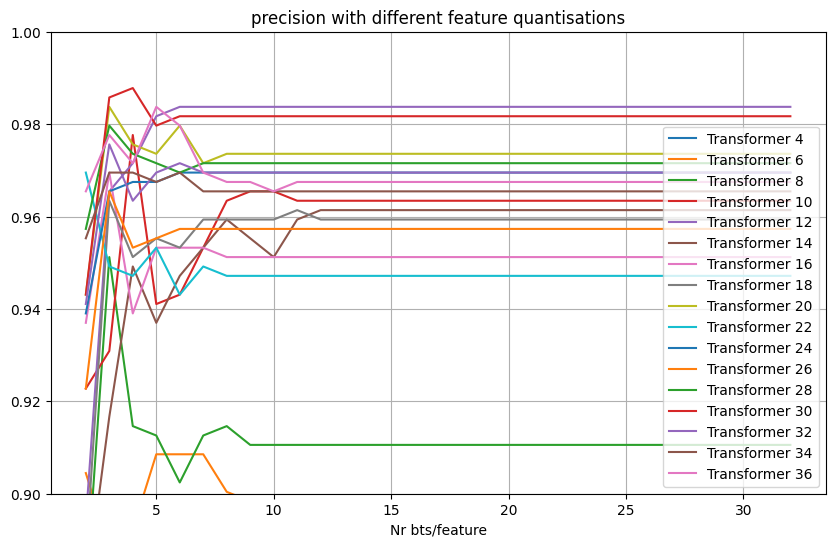

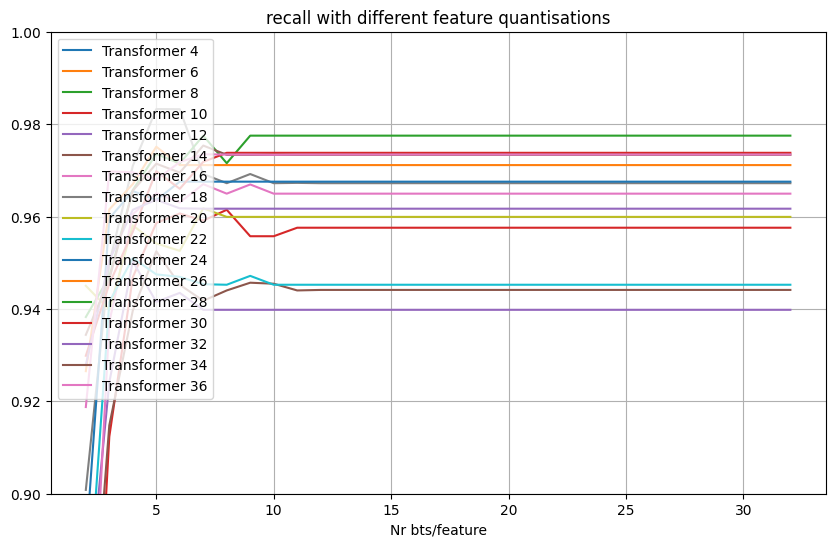

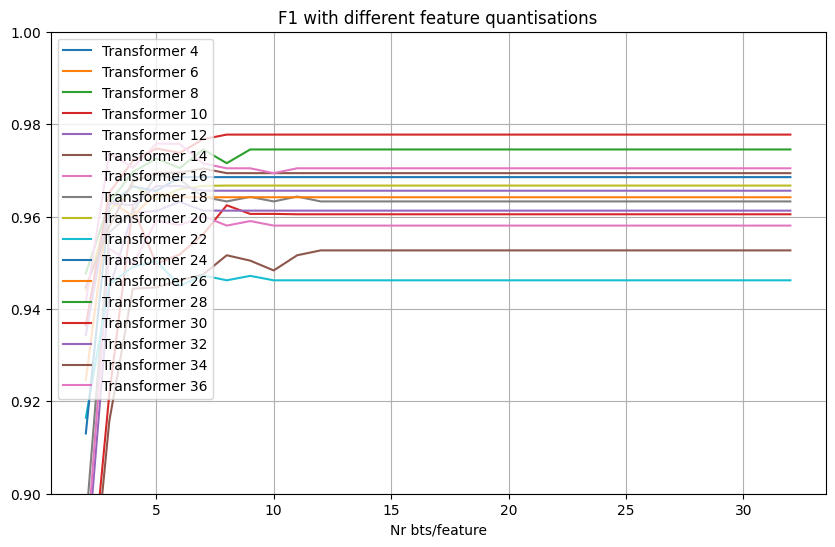

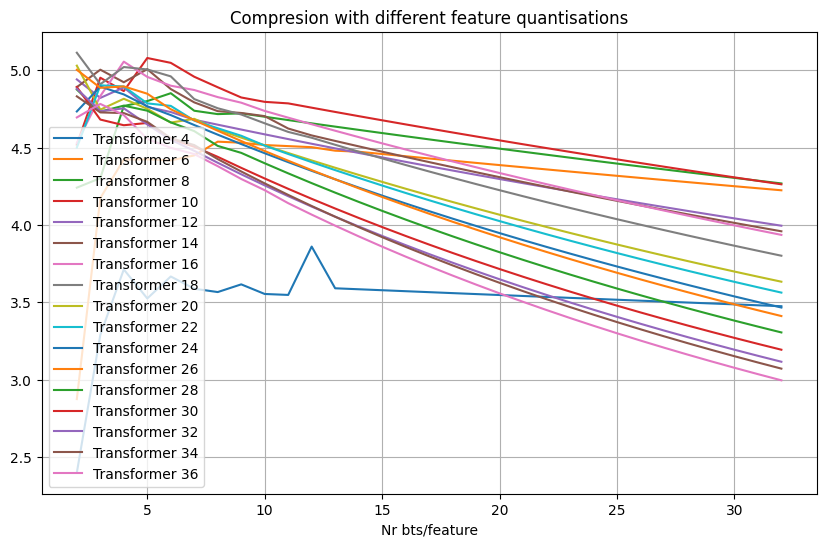

In [13]:
plt.figure(figsize=(10,6))
for out_size, id in best_models['Transformer']:
    m = Model(m_name='Transformer',out_size=out_size,id=id)
    metrics = []
    x = []
    quantization = range(2,33)
    for q in quantization:
        m.quantize(q)
        metrics.append(m.test_metrics)
        x.append(q) # x.append(q*out_size)

    metrics=np.array(metrics)
    plt.plot(x,metrics[:,0],label=f'Transformer {out_size}')

plt.grid(True)
plt.legend()
plt.title('precision with different feature quantisations')
plt.xlabel('Nr bts/feature')
plt.ylim(0.9,1)
plt.show()
plt.figure(figsize=(10,6))
for out_size, id in best_models['Transformer']:
    m = Model(m_name='Transformer',out_size=out_size,id=id)
    metrics = []
    x = []
    quantization = range(2,33)
    for q in quantization:
        m.quantize(q)
        metrics.append(m.test_metrics)
        x.append(q) # x.append(q*out_size)

    metrics=np.array(metrics)
    plt.plot(x,metrics[:,1],label=f'Transformer {out_size}')

plt.grid(True)
plt.legend()
plt.title('recall with different feature quantisations')
plt.xlabel('Nr bts/feature')
plt.ylim(0.9,1)
plt.show()

plt.figure(figsize=(10,6))
for out_size, id in best_models['Transformer']:
    m = Model(m_name='Transformer',out_size=out_size,id=id)
    metrics = []
    x = []
    quantization = range(2,33)
    for q in quantization:
        m.quantize(q)
        metrics.append(m.test_metrics)
        x.append(q) # x.append(q*out_size)

    metrics=np.array(metrics)
    plt.plot(x,metrics[:,2],label=f'Transformer {out_size}')

plt.grid(True)
plt.legend()
plt.title('F1 with different feature quantisations')
plt.xlabel('Nr bts/feature')
plt.ylim(0.9,1)
plt.show()


plt.figure(figsize=(10,6))
for out_size, id in best_models['Transformer']:
    m = Model(m_name='Transformer',out_size=out_size,id=id)
    metrics = []
    x = []
    quantization = range(2,33)
    for q in quantization:
        m.quantize(q)
        metrics.append(m.test_metrics)
        x.append(q) # x.append(q*out_size)

    metrics=np.array(metrics)
    plt.plot(x,metrics[:,3],label=f'Transformer {out_size}')

plt.grid(True)
plt.legend()
plt.title('Compresion with different feature quantisations')
plt.xlabel('Nr bts/feature')

plt.show()


/tmp/ipykernel_433960/4247088273.py:112: RuntimeWarning: invalid value encountered in divide
  f1 = np.nan_to_num(2*precision*recall/(precision+recall))


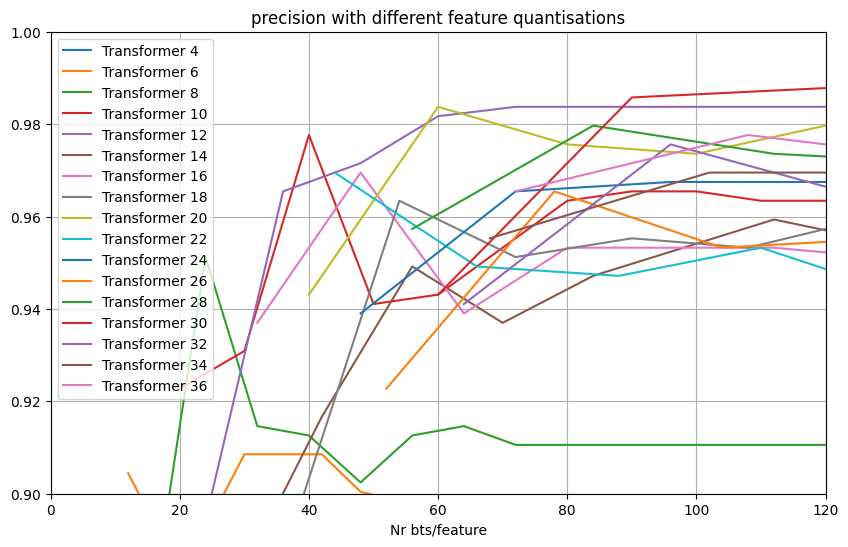

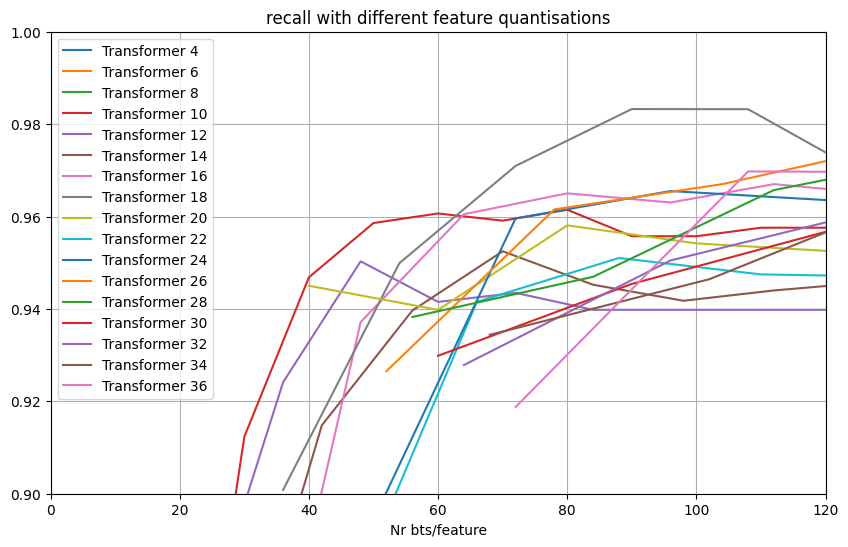

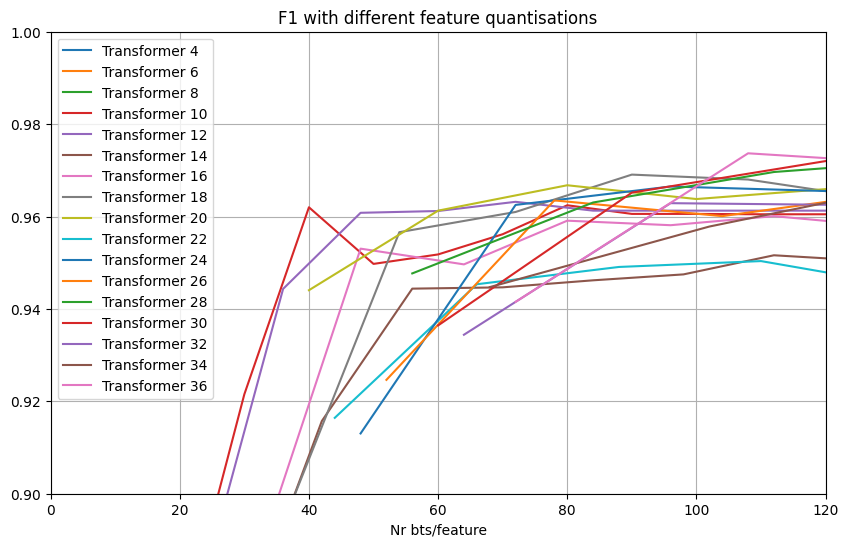

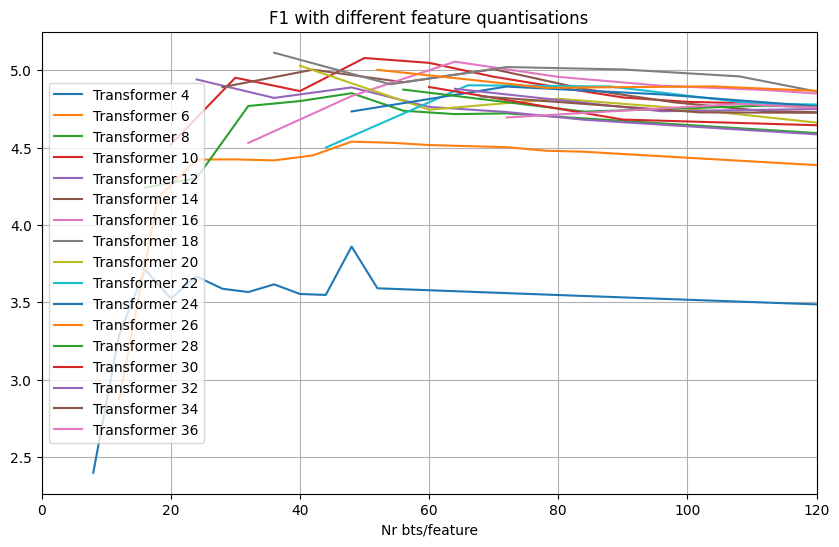

In [16]:
plt.figure(figsize=(10,6))
for out_size, id in best_models['Transformer']:
    m = Model(m_name='Transformer',out_size=out_size,id=id)
    metrics = []
    x = []
    quantization = range(2,33)
    for q in quantization:
        m.quantize(q)
        metrics.append(m.test_metrics)
        x.append(q*out_size)

    metrics=np.array(metrics)
    plt.plot(x,metrics[:,0],label=f'Transformer {out_size}')

plt.grid(True)
plt.xlim(0,120)
plt.legend()
plt.title('precision with different feature quantisations')
plt.xlabel('Nr bts/feature')
plt.ylim(0.9,1)
plt.show()
plt.figure(figsize=(10,6))
for out_size, id in best_models['Transformer']:
    m = Model(m_name='Transformer',out_size=out_size,id=id)
    metrics = []
    x = []
    quantization = range(2,33)
    for q in quantization:
        m.quantize(q)
        metrics.append(m.test_metrics)
        x.append(q*out_size)

    metrics=np.array(metrics)
    plt.plot(x,metrics[:,1],label=f'Transformer {out_size}')

plt.grid(True)
plt.legend()
plt.title('recall with different feature quantisations')
plt.xlabel('Nr bts/feature')
plt.ylim(0.9,1)
plt.xlim(0,120)
plt.show()

plt.figure(figsize=(10,6))
for out_size, id in best_models['Transformer']:
    m = Model(m_name='Transformer',out_size=out_size,id=id)
    metrics = []
    x = []
    quantization = range(2,33)
    for q in quantization:
        m.quantize(q)
        metrics.append(m.test_metrics)
        x.append(q*out_size)

    metrics=np.array(metrics)
    plt.plot(x,metrics[:,2],label=f'Transformer {out_size}')

plt.grid(True)
plt.legend()
plt.title('F1 with different feature quantisations')
plt.xlabel('Nr bts/feature')
plt.ylim(0.9,1)
plt.xlim(0,120)
plt.show()

plt.figure(figsize=(10,6))
for out_size, id in best_models['Transformer']:
    m = Model(m_name='Transformer',out_size=out_size,id=id)
    metrics = []
    x = []
    quantization = range(2,33)
    for q in quantization:
        m.quantize(q)
        metrics.append(m.test_metrics)
        x.append(q*out_size)

    metrics=np.array(metrics)
    plt.plot(x,metrics[:,3],label=f'Transformer {out_size}')

plt.grid(True)
plt.legend()
plt.title('F1 with different feature quantisations')
plt.xlabel('Nr bts/feature')
# plt.ylim(0.9,1)
plt.xlim(0,120)
plt.show()

In [5]:
0.36003914
(0.8846284356973193, 0.7651893161138832, 0.8205854579792257, 0.9246380643881801)
(0.8495934959349594, 0.7231833910034602, 0.7813084112149532, 0.9075829383886256)

(0.8495934959349594,
 0.7231833910034602,
 0.7813084112149532,
 0.9075829383886256)

In [6]:
class Quantizer:
    """ This quantizer is build around the train data and applied to the test_data"""
    def __init__(self,features:np.ndarray, n_bits=8):
        self.k = 2 ** n_bits
        f_min = np.min(features, axis=0, keepdims=True)
        f_max = np.max(features, axis=0, keepdims=True)
    
        scale = (f_max - f_min) / (self.k - 1)
        scale[scale == 0] = 1e-8  # Prevent division by zero

        self.f_min=f_min
        self.scale = scale

    def quantize(self,seq):
        return np.round((seq - self.f_min) / self.scale)  # or smaller dtype depending on bits
    def dequantize(self,seq):
        return self.f_min + seq * self.scale


test = np.random.random((16,4))-0.5
t2 = np.random.random((16,4))-0.5
print(np.concatenate([test,t2]).shape)
q = Quantizer(test,64)
print(q.f_min)
p = q.dequantize(q.quantize(test))
for i, j in zip(test, p):
    print(i, j, i-j)

(32, 4)
[[-0.46264398 -0.49399152 -0.33380225 -0.48707349]]
[-0.17038208 -0.11143309 -0.20836772  0.14840086] [-0.17038208 -0.11143309 -0.20836772  0.14840086] [0. 0. 0. 0.]
[-0.46264398  0.07869351 -0.25029674 -0.06795302] [-0.46264398  0.07869351 -0.25029674 -0.06795302] [0. 0. 0. 0.]
[ 0.00423768  0.02847698  0.40926782 -0.36722382] [ 0.00423768  0.02847698  0.40926782 -0.36722382] [0. 0. 0. 0.]
[-0.13138965  0.08276374  0.12102536 -0.37657061] [-0.13138965  0.08276374  0.12102536 -0.37657061] [ 0.00000000e+00  0.00000000e+00 -5.55111512e-17  0.00000000e+00]
[-0.22007649 -0.47852058  0.07779248 -0.48707349] [-0.22007649 -0.47852058  0.07779248 -0.48707349] [-2.77555756e-17  0.00000000e+00  0.00000000e+00  0.00000000e+00]
[-0.45161175  0.03657225  0.27303456 -0.4759344 ] [-0.45161175  0.03657225  0.27303456 -0.4759344 ] [0. 0. 0. 0.]
[-0.33823349 -0.40901399  0.49388093  0.17240233] [-0.33823349 -0.40901399  0.49388093  0.17240233] [0. 0. 0. 0.]
[0.40324879 0.48210351 0.06544815 0.15

# Best models 
We trained each model 4 times with different sizes. The best model has the lowest region of confusion. Idea: calculate the 99% recall th. The model with the lowest false positives wins. 

# Quantization 
1. !first produce the fingerprints for samples (maybe on all detections)!
2. Find all pairwise hamming of 0 
3. Group all 